In [1]:

!git clone -b EMT https://github.com/pop756/Quantum_KAN.git
%cd Quantum_KAN
!pip install -r requirements.txt

Cloning into 'Quantum_KAN'...
remote: Enumerating objects: 945, done.
remote: Counting objects: 100% (108/108), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 945 (delta 43), reused 50 (delta 14), pack-reused 837
Receiving objects: 100% (945/945), 29.33 MiB | 11.12 MiB/s, done.
Resolving deltas: 100% (161/161), done.
/content/Quantum_KAN
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 9.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.2/69.2 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 13.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 22.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 25.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 9.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.9/249.9 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import *
from qiskit.quantum_info import Operator, Statevector, Pauli
from qiskit.visualization import plot_bloch_vector

# Define the Pauli matrices
X = np.array([[0, 1], [1, 0]])
Y = np.array([[0, -1j], [1j, 0]])
Z = np.array([[1, 0], [0, -1]])

# Hamiltonian coefficients
a = 1.0
b = 0.5
c = -0.8

# Define the Hamiltonian
H = a * X + b * Y + c * Z

# Define the time evolution operator U(t) = exp(-iHt)
def U(t):
    return expm(-1j * H * t)

# Time evolution and visualization on the Bloch sphere
time_points = np.linspace(0, 10, 200)
bloch_vectors = []

# Initial state |0>
initial_state = Statevector.from_label('0')

for t in time_points:
    evolved_state = initial_state.evolve(Operator(U(t)))
    bloch_vectors.append(evolved_state.data)

# Function to convert a state vector to a Bloch vector
def bloch_vector(state):
    return [np.real(state.conj().T @ Pauli('X').to_matrix() @ state)[0, 0],
            np.real(state.conj().T @ Pauli('Y').to_matrix() @ state)[0, 0],
            np.real(state.conj().T @ Pauli('Z').to_matrix() @ state)[0, 0]]

# Calculate Bloch vectors for all time points
bloch_points = np.array([bloch_vector(Statevector(v)) for v in bloch_vectors])

# Plot the Bloch sphere and the path of the quantum state
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.quiver(0, 0, 0, bloch_points[0,0], bloch_points[0,1], bloch_points[0,2], color='r', label='Start')
ax.plot(bloch_points[:,0], bloch_points[:,1], bloch_points[:,2], label='Evolution Path')
ax.quiver(0, 0, 0, bloch_points[-1,0], bloch_points[-1,1], bloch_points[-1,2], color='b', label='End')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.title('Time Evolution of Quantum State on Bloch Sphere')
plt.show()


NameError: name 'expm' is not defined

In [11]:
from functions.Train_ZNE import update_pulse
import json
import numpy as np

with open('./offset_minus_strasbourg_ecr_data_second_x.json','r') as file:
    config_list = json.load(file)

    
config_list[2]

{'init': [79, 78],
 'cr_amp': 0.15705452133899034,
 'cr_angle': 2.487453161551187,
 'x_amp_1': -0.04461538461538461,
 'x_amp_2': -0.03948717948717949,
 'x_amp_3': -0.03435897435897436,
 'y': 0.00026097981075375037,
 'offset': -3598.336594911947,
 'beta': 0,
 'second': -0.03439718461666068}

: 

In [3]:
# Configure JAX
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")

In [63]:
import numpy as np

dim = 3

v0 = 4.86e9
anharm0 = -0.5e9
r0 = 0.22e9

v1 = (4.97)*1e9
anharm1 = -0.5e9
r1 = 0.26e9

J = 0.002e9

a = np.diag(np.sqrt(np.arange(1, dim)), 1)
adag = np.diag(np.sqrt(np.arange(1, dim)), -1)
N = np.diag(np.arange(dim))

ident = np.eye(dim, dtype=complex)
full_ident = np.eye(dim**2, dtype=complex)

N0 = np.kron(ident, N)
N1 = np.kron(N, ident)

a0 = np.kron(ident, a)
a1 = np.kron(a, ident)

a0dag = np.kron(ident, adag)
a1dag = np.kron(adag, ident)


static_ham0 = 2 * np.pi * v0 * N0 + np.pi * anharm0 * N0 * (N0 - full_ident)
static_ham1 = 2 * np.pi * v1 * N1 + np.pi * anharm1 * N1 * (N1 - full_ident)

static_ham_full = static_ham0 + static_ham1 + 2 * np.pi * J * ((a0 + a0dag) @ (a1 + a1dag))

drive_op0 = 2 * np.pi * r0 * (a0 + a0dag)
drive_op1 = 2 * np.pi * r1 * (a1 + a1dag)

In [62]:
from qiskit_dynamics import Solver

# build solver
dt = 1/4.5e9

solver = Solver(
    static_hamiltonian=static_ham_full,
    hamiltonian_operators=[drive_op0, drive_op1, drive_op0, drive_op1],
    rotating_frame=static_ham_full,
    hamiltonian_channels=["d0", "d1", "u0", "u1"],
    channel_carrier_freqs={"d0": v0, "d1": v1, "u0": v1, "u1": v0},
    dt=dt,
    array_library="jax",
)

In [6]:
from qiskit_dynamics import DynamicsBackend

# Consistent solver option to use throughout notebook
solver_options = {"method": "jax_odeint", "atol": 1e-6, "rtol": 1e-8, "hmax": dt}

backend = DynamicsBackend(
    solver=solver,
    subsystem_dims=[dim, dim], # for computing measurement data
    solver_options=solver_options, # to be used every time run is called
)

In [7]:
%%time

from qiskit import pulse

sigma = 128
num_samples = 256

schedules = []

for amp in np.linspace(0., 1., 10):
    gauss = pulse.library.Gaussian(
        num_samples, amp, sigma, name="Parametric Gauss"
    )

    with pulse.build() as schedule:
        with pulse.align_sequential():
            pulse.play(gauss, pulse.DriveChannel(0))
            pulse.shift_phase(0.5, pulse.DriveChannel(0))
            pulse.shift_frequency(0.1, pulse.DriveChannel(0))
            pulse.play(gauss, pulse.DriveChannel(0))
            pulse.acquire(duration=1, qubit_or_channel=0, register=pulse.MemorySlot(0))

    schedules.append(schedule)

job = backend.run(schedules, shots=100)
result = job.result()

CPU times: user 3.39 s, sys: 213 ms, total: 3.6 s
Wall time: 7.65 s


In [8]:
from qiskit.circuit.library import XGate, SXGate, RZGate, CXGate
from qiskit.circuit import Parameter
from qiskit.providers.backend import QubitProperties
from qiskit.circuit.library import HGate
from qiskit.transpiler import InstructionProperties

target = backend.target

# qubit properties
target.qubit_properties = [QubitProperties(frequency=v0), QubitProperties(frequency=v1)]

# add instructions
target.add_instruction(XGate(), properties={(0,): None, (1,): None})
target.add_instruction(SXGate(), properties={(0,): None, (1,): None})

target.add_instruction(CXGate(), properties={(0, 1): None, (1, 0): None})

# Add RZ instruction as phase shift for drag cal
phi = Parameter("phi")
with pulse.build() as rz0:
    pulse.shift_phase(phi, pulse.DriveChannel(0))
    pulse.shift_phase(phi, pulse.ControlChannel(1))

with pulse.build() as rz1:
    pulse.shift_phase(phi, pulse.DriveChannel(1))
    pulse.shift_phase(phi, pulse.ControlChannel(0))

target.add_instruction(
    RZGate(phi),
    {(0,): InstructionProperties(calibration=rz0), (1,): InstructionProperties(calibration=rz1)}
)

In [9]:
import pandas as pd
from qiskit_experiments.calibration_management.calibrations import Calibrations
from qiskit_experiments.calibration_management.basis_gate_library import FixedFrequencyTransmon

cals = Calibrations(libraries=[FixedFrequencyTransmon(basis_gates=['x', 'sx'])])

pd.DataFrame(**cals.parameters_table(qubit_list=[0,1, ()]))

,parameter,qubits,schedule,value,group,valid,date_time,exp_id
0,amp,(),sx,0.25,default,True,2024-07-13 18:57:31.350758+0000,None
1,σ,(),x,40.00,default,True,2024-07-13 18:57:31.350654+0000,None
2,β,(),x,0.00,default,True,2024-07-13 18:57:31.350700+0000,None
3,σ,(),sx,40.00,default,True,2024-07-13 18:57:31.350745+0000,None
4,β,(),sx,0.00,default,True,2024-07-13 18:57:31.350773+0000,None
5,duration,(),x,160.00,default,True,2024-07-13 18:57:31.350683+0000,None
6,angle,(),x,0.00,default,True,2024-07-13 18:57:31.350715+0000,None
7,amp,(),x,0.50,default,True,2024-07-13 18:57:31.350606+0000,None
8,duration,(),sx,160.00,default,True,2024-07-13 18:57:31.350788+0000,None
9,angle,(),sx,0.00,default,True,2024-07-13 18:57:31.350731+0000,None


In [10]:
from qiskit_experiments.library.calibration import RoughXSXAmplitudeCal

# rabi experiments for qubit 0
rabi0 = RoughXSXAmplitudeCal([0], cals, backend=backend, amplitudes=np.linspace(-0.2, 0.2, 27))

# rabi experiments for qubit 1
rabi1 = RoughXSXAmplitudeCal([1], cals, backend=backend, amplitudes=np.linspace(-0.2, 0.2, 27))

In [11]:
%%time
rabi0_data = rabi0.run().block_for_results()
rabi1_data = rabi1.run().block_for_results()

CPU times: user 11.3 s, sys: 394 ms, total: 11.7 s
Wall time: 17.5 s


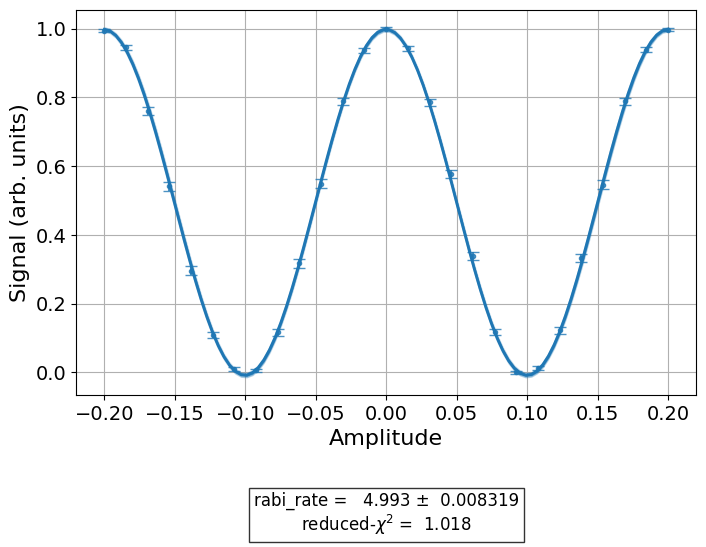

In [12]:
rabi1_data.figure(0)

In [13]:
# set the control channel map
backend.set_options(control_channel_map={(0, 1): 0, (1, 0): 1})

In [14]:
pd.DataFrame(**cals.parameters_table(qubit_list=[0, ()], parameters="amp"))

,parameter,qubits,schedule,value,group,valid,date_time,exp_id
0,amp,(),sx,0.250000,default,True,2024-07-13 18:57:31.350758+0000,None
1,amp,"(0,)",sx,0.059072,default,True,2024-07-13 18:57:36.780235+0000,e19b9d86-393d-43c9-88e9-bb483b0cc752
2,amp,(),x,0.500000,default,True,2024-07-13 18:57:31.350606+0000,None
3,amp,"(0,)",x,0.118144,default,True,2024-07-13 18:57:36.780235+0000,e19b9d86-393d-43c9-88e9-bb483b0cc752


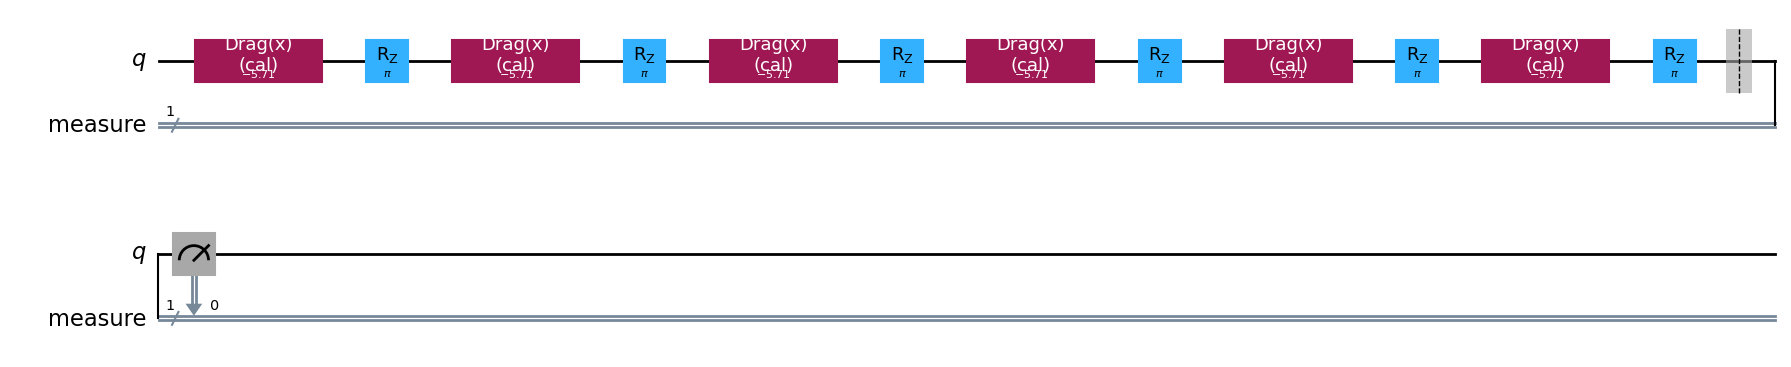

In [15]:
from qiskit_experiments.library.calibration import RoughDragCal

cal_drag0 = RoughDragCal([0], cals, backend=backend, betas=np.linspace(-20, 20, 15))
cal_drag1 = RoughDragCal([1], cals, backend=backend, betas=np.linspace(-20, 20, 15))

cal_drag0.set_experiment_options(reps=[3, 5, 7])
cal_drag1.set_experiment_options(reps=[3, 5, 7])

cal_drag0.circuits()[5].draw(output="mpl")

In [16]:
%%time
drag0_data = cal_drag0.run().block_for_results()
drag1_data = cal_drag1.run().block_for_results()

CPU times: user 1min 2s, sys: 7.51 s, total: 1min 10s
Wall time: 1min 19s


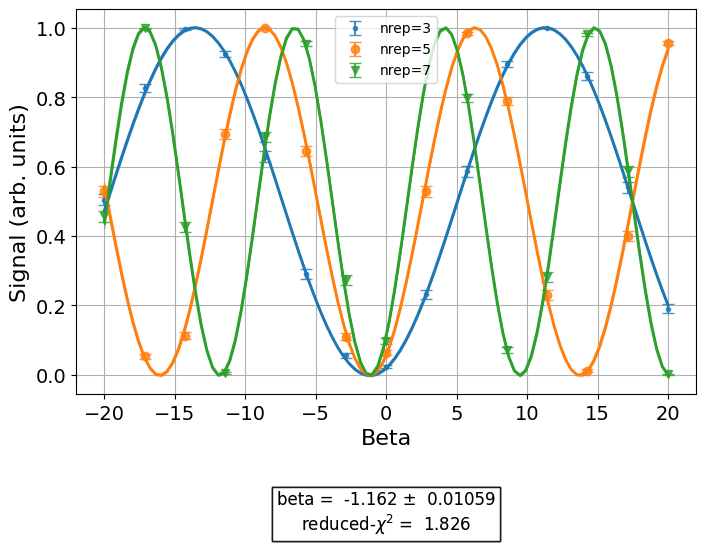

In [17]:
drag1_data.figure(0)

In [18]:
pd.DataFrame(**cals.parameters_table(qubit_list=[1, ()], parameters="amp"))

,parameter,qubits,schedule,value,group,valid,date_time,exp_id
0,amp,(),sx,0.250000,default,True,2024-07-13 18:57:31.350758+0000,None
1,amp,"(1,)",sx,0.050073,default,True,2024-07-13 18:57:45.675276+0000,7c6ae2d4-f3c1-40d8-8385-7e0d7bd19756
2,amp,"(1,)",x,0.100146,default,True,2024-07-13 18:57:45.675276+0000,7c6ae2d4-f3c1-40d8-8385-7e0d7bd19756
3,amp,(),x,0.500000,default,True,2024-07-13 18:57:31.350606+0000,None


In [19]:
backend.target.update_from_instruction_schedule_map(cals.get_inst_map())

In [20]:
# set the control channel map
backend.set_options(control_channel_map={(0, 1): 0, (1, 0): 1})

In [21]:
from qiskit_experiments.library import CrossResonanceHamiltonian
from qiskit import circuit
class CrossResonanceHamiltonian_angle(CrossResonanceHamiltonian):
    r"""Echoed cross resonance Hamiltonian tomography experiment.

    # section: overview

        This is a variant of :class:`CrossResonanceHamiltonian`
        for which the experiment framework is identical but the
        cross resonance operation is realized as an echoed sequence
        to remove unwanted single qubit rotations. The cross resonance
        circuit looks like:

        .. parsed-literal::

                 ┌────────────────────┐  ┌───┐  ┌────────────────────┐
            q_0: ┤0                   ├──┤ X ├──┤0                   ├──────────
                 │  cr_tone(duration) │┌─┴───┴─┐│  cr_tone(duration) │┌────────┐
            q_1: ┤1                   ├┤ Rz(π) ├┤1                   ├┤ Rz(-π) ├
                 └────────────────────┘└───────┘└────────────────────┘└────────┘

        Here two ``cr_tone`` are applied, where the latter one is with the
        control qubit state flipped and with a phase flip of the target qubit frame.
        This operation is equivalent to applying the ``cr_tone`` with a negative amplitude.
        The Hamiltonian for this decomposition has no IX and ZI interactions,
        and also a reduced IY interaction to some extent (not completely eliminated) [1].
        Note that the CR Hamiltonian tomography experiment cannot detect the ZI term.
        However, it is sensitive to the IX and IY terms.

    # section: reference
        .. ref_arxiv:: 1 2007.02925

    """
    num_pulses = 1


    def __init__(self,c_angle,x_angle ,*args, **kwargs):
        super(CrossResonanceHamiltonian_angle, self).__init__(*args, **kwargs)
        self.c_angle = c_angle
        self.x_angle = x_angle



    def _build_default_schedule(self) -> pulse.ScheduleBlock:
        """GaussianSquared cross resonance pulse.

        Returns:
            A schedule definition for the cross resonance pulse to measure.
        """
        opt = self.experiment_options
        duration = circuit.Parameter("duration")

        cr_drive = self._backend_data.control_channel(self.physical_qubits)[0]
        c_drive = self._backend_data.drive_channel(self.physical_qubits[0])
        t_drive = self._backend_data.drive_channel(self.physical_qubits[1])

        with pulse.build(default_alignment="left", name="cr") as cross_resonance:
            # add cross resonance tone
            pulse.play(
                pulse.GaussianSquare(
                    duration=duration,
                    amp=opt.amp,
                    sigma=opt.sigma,
                    risefall_sigma_ratio=opt.risefall,
                    angle = self.c_angle
                ),
                cr_drive,
            )
            # add cancellation tone
            if not np.isclose(opt.amp_t, 0.0):
                pulse.play(
                    pulse.GaussianSquare(
                        duration=duration,
                        amp=opt.amp_t,
                        sigma=opt.sigma,
                        risefall_sigma_ratio=opt.risefall,
                        angle = self.x_angle
                    ),
                    t_drive,
                )
            else:
                pulse.delay(duration, t_drive)

            # place holder for empty drive channels. this is necessary due to known pulse gate bug.
            pulse.delay(duration, c_drive)

        return cross_resonance

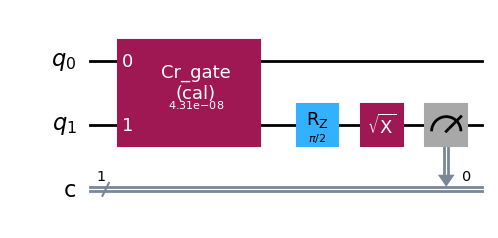

In [22]:
from qiskit import schedule
from qiskit.circuit import Gate
resonance_7 = 0.0025*9.1
cr_ham_experiment = CrossResonanceHamiltonian_angle(
    physical_qubits=(0, 1),
    durations=np.linspace(1e-7, 6e-7, 17),
    amp = 0.3,
    amp_t = resonance_7,
    c_angle = 0,
    x_angle = 0,
    backend=backend,
)

backend.target.update_from_instruction_schedule_map(cals.get_inst_map())
cr_ham_experiment.circuits()[0].draw("mpl")

In [23]:
%time data_cr = cr_ham_experiment.run().block_for_results()

CPU times: user 25.5 s, sys: 2.79 s, total: 28.3 s
Wall time: 25.8 s


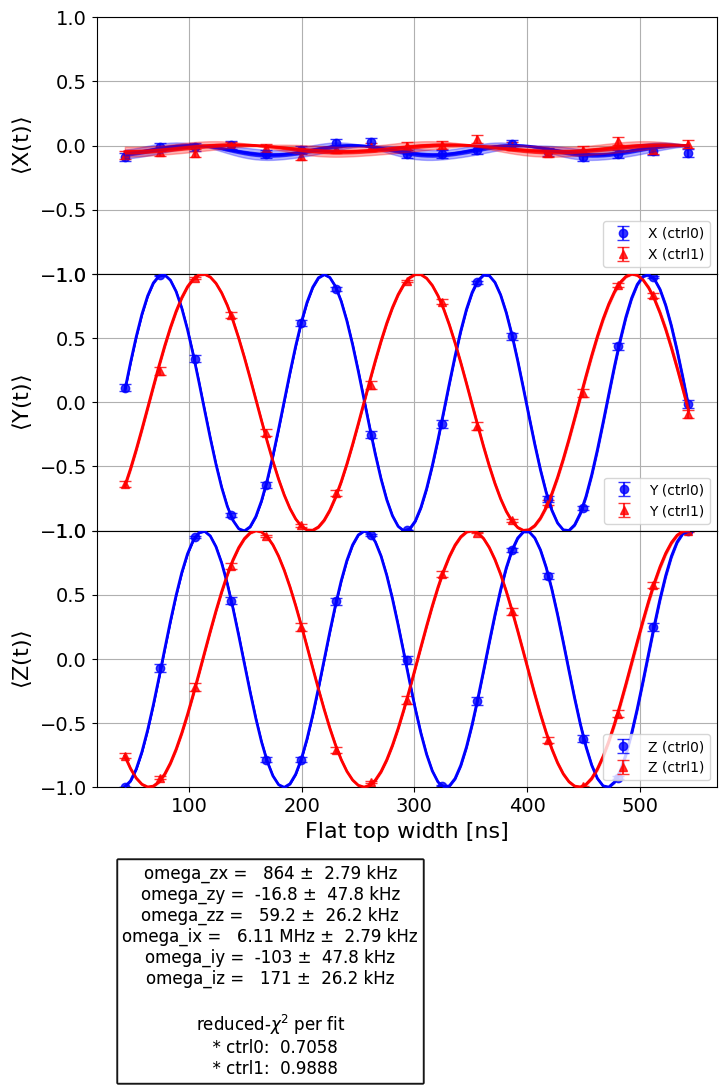

In [24]:
data_cr.figure(0)

In [74]:
from qiskit import circuit
from qiskit import QuantumCircuit
class EchoedCrossResonanceHamiltonian_double(CrossResonanceHamiltonian_angle):
    r"""Echoed cross resonance Hamiltonian tomography experiment.

    # section: overview

        This is a variant of :class:`CrossResonanceHamiltonian`
        for which the experiment framework is identical but the
        cross resonance operation is realized as an echoed sequence
        to remove unwanted single qubit rotations. The cross resonance
        circuit looks like:

        .. parsed-literal::

                 ┌────────────────────┐  ┌───┐  ┌────────────────────┐
            q_0: ┤0                   ├──┤ X ├──┤0                   ├──────────
                 │  cr_tone(duration) │┌─┴───┴─┐│  cr_tone(duration) │┌────────┐
            q_1: ┤1                   ├┤ Rz(π) ├┤1                   ├┤ Rz(-π) ├
                 └────────────────────┘└───────┘└────────────────────┘└────────┘

        Here two ``cr_tone`` are applied, where the latter one is with the
        control qubit state flipped and with a phase flip of the target qubit frame.
        This operation is equivalent to applying the ``cr_tone`` with a negative amplitude.
        The Hamiltonian for this decomposition has no IX and ZI interactions,
        and also a reduced IY interaction to some extent (not completely eliminated) [1].
        Note that the CR Hamiltonian tomography experiment cannot detect the ZI term.
        However, it is sensitive to the IX and IY terms.

    # section: reference
        .. ref_arxiv:: 1 2007.02925

    """
    #num_pulses = 4
    num_pulses = 2
    def _build_cr_circuit(self, pulse_gate: circuit.Gate) -> QuantumCircuit:
        """Single tone cross resonance.

        Args:
            pulse_gate: A pulse gate to represent a single cross resonance pulse.

        Returns:
            A circuit definition for the cross resonance pulse to measure.
        """
        ''' cr_circuit = QuantumCircuit(2)
        cr_circuit.append(pulse_gate, [0, 1])
        cr_circuit.x(0)
        cr_circuit.rz(np.pi, 1)
        cr_circuit.append(pulse_gate, [0, 1])
        cr_circuit.rz(-np.pi, 1)
        cr_circuit.x(0)



        cr_circuit.rz(np.pi, 1)
        cr_circuit.append(pulse_gate, [0, 1])
        cr_circuit.rz(-np.pi, 1)
        cr_circuit.x(0)
        cr_circuit.append(pulse_gate, [0, 1])
        cr_circuit.x(0) '''

        ## 다른 실험해볼거
        cr_circuit = QuantumCircuit(2)
        cr_circuit.append(pulse_gate, [0, 1])
        cr_circuit.rz(np.pi, 1)
        cr_circuit.append(pulse_gate, [0, 1])
        cr_circuit.rz(-np.pi, 1)


        cr_circuit.x(1)
        cr_circuit.x(0)
        cr_circuit.append(pulse_gate, [0, 1])
        cr_circuit.rz(-np.pi, 1)
        cr_circuit.append(pulse_gate, [0, 1])
        cr_circuit.rz(np.pi, 1)
        cr_circuit.x(0)
        cr_circuit.x(1)

        '''  cr_circuit = QuantumCircuit(2)
        cr_circuit.append(pulse_gate, [0, 1])
        cr_circuit.x(0)
        cr_circuit.x(1)
        cr_circuit.append(pulse_gate, [0, 1])
        cr_circuit.x(0)
        cr_circuit.x(1) '''
        return cr_circuit


In [31]:
from qiskit import circuit
from qiskit import QuantumCircuit
class EchoedCrossResonanceHamiltonian(CrossResonanceHamiltonian_angle):
    r"""Echoed cross resonance Hamiltonian tomography experiment.

    # section: overview

        This is a variant of :class:`CrossResonanceHamiltonian`
        for which the experiment framework is identical but the
        cross resonance operation is realized as an echoed sequence
        to remove unwanted single qubit rotations. The cross resonance
        circuit looks like:

        .. parsed-literal::

                 ┌────────────────────┐  ┌───┐  ┌────────────────────┐
            q_0: ┤0                   ├──┤ X ├──┤0                   ├──────────
                 │  cr_tone(duration) │┌─┴───┴─┐│  cr_tone(duration) │┌────────┐
            q_1: ┤1                   ├┤ Rz(π) ├┤1                   ├┤ Rz(-π) ├
                 └────────────────────┘└───────┘└────────────────────┘└────────┘

        Here two ``cr_tone`` are applied, where the latter one is with the
        control qubit state flipped and with a phase flip of the target qubit frame.
        This operation is equivalent to applying the ``cr_tone`` with a negative amplitude.
        The Hamiltonian for this decomposition has no IX and ZI interactions,
        and also a reduced IY interaction to some extent (not completely eliminated) [1].
        Note that the CR Hamiltonian tomography experiment cannot detect the ZI term.
        However, it is sensitive to the IX and IY terms.

    # section: reference
        .. ref_arxiv:: 1 2007.02925

    """
    num_pulses = 2

    def _build_cr_circuit(self, pulse_gate: circuit.Gate) -> QuantumCircuit:
        """Single tone cross resonance.

        Args:
            pulse_gate: A pulse gate to represent a single cross resonance pulse.

        Returns:
            A circuit definition for the cross resonance pulse to measure.
        """
        cr_circuit = QuantumCircuit(2)
        cr_circuit.append(pulse_gate, [0, 1])
        cr_circuit.x(0)
        cr_circuit.rz(np.pi, 1)
        cr_circuit.append(pulse_gate, [0, 1])
        cr_circuit.rz(-np.pi, 1)

        return cr_circuit

In [32]:
import math

def angle_amp(real,imag):

  # 크기 계산
  amp = math.sqrt(real**2 + imag**2)

  # 각도 계산 (라디안 단위)
  angle = math.atan2(imag, real)
  return amp,angle

In [33]:
resonance_7

0.02275

In [34]:
angle_amp(resonance_7,0.0004)

(0.02275351621178582, 0.01758060610063206)

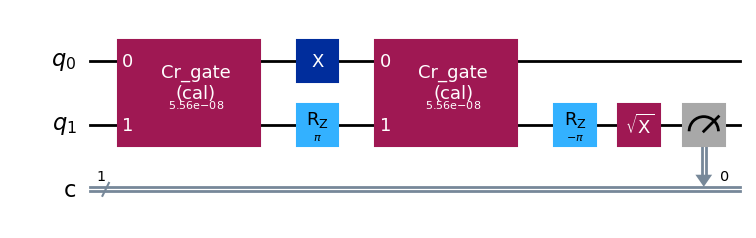

In [72]:
from qiskit_experiments.library import CrossResonanceHamiltonian
from qiskit.circuit import Gate
cr_ham_experiment = EchoedCrossResonanceHamiltonian(
    physical_qubits=(0, 1),
    durations=np.linspace(1e-7, 3e-7, 17),
    amp = 0.3,
    amp_t = 0.02275351621178582,
    backend=backend,
    c_angle = 0,
    x_angle = 0.01758060610063206,

)

backend.target.update_from_instruction_schedule_map(cals.get_inst_map())
cr_ham_experiment.circuits()[7].draw("mpl")

In [56]:
%time data_cr = cr_ham_experiment.run().block_for_results()

CPU times: user 24.7 s, sys: 2.88 s, total: 27.6 s
Wall time: 27.6 s


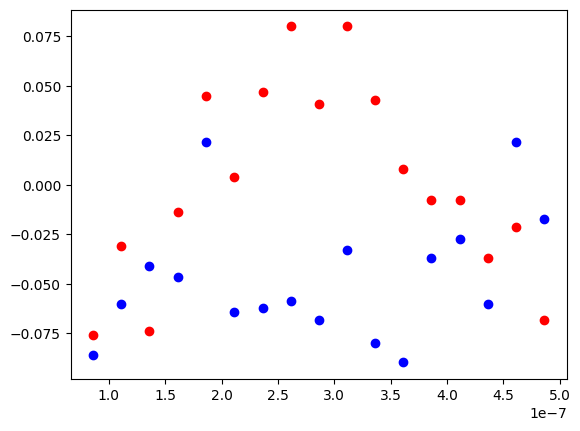

In [57]:
# 첫 번째 플롯
import matplotlib.pyplot as plt
x_list =[]
data_list_0 = []
data_list_1 = []

for data in data_cr.data():
  if data['metadata']['meas_basis'] == 'x':
    if data['metadata']['control_state'] == 0:
        x_list.append(data['metadata']['xval'])
        try:
          count_1 = data['counts']['1']
        except:
          count_1 =0
        data_list_0.append((data['counts']['0']-count_1)/(data['counts']['0']+count_1))
    else:
        try:
            count_1 = data['counts']['1']
        except:
          count_1 =0
        data_list_1.append((data['counts']['0']-count_1)/(data['counts']['0']+count_1))

plt.plot(x_list,data_list_0,'bo')
plt.plot(x_list,data_list_1,'ro')

#plt.ylim(,1)
plt.show() # 0.0025*9.1*2

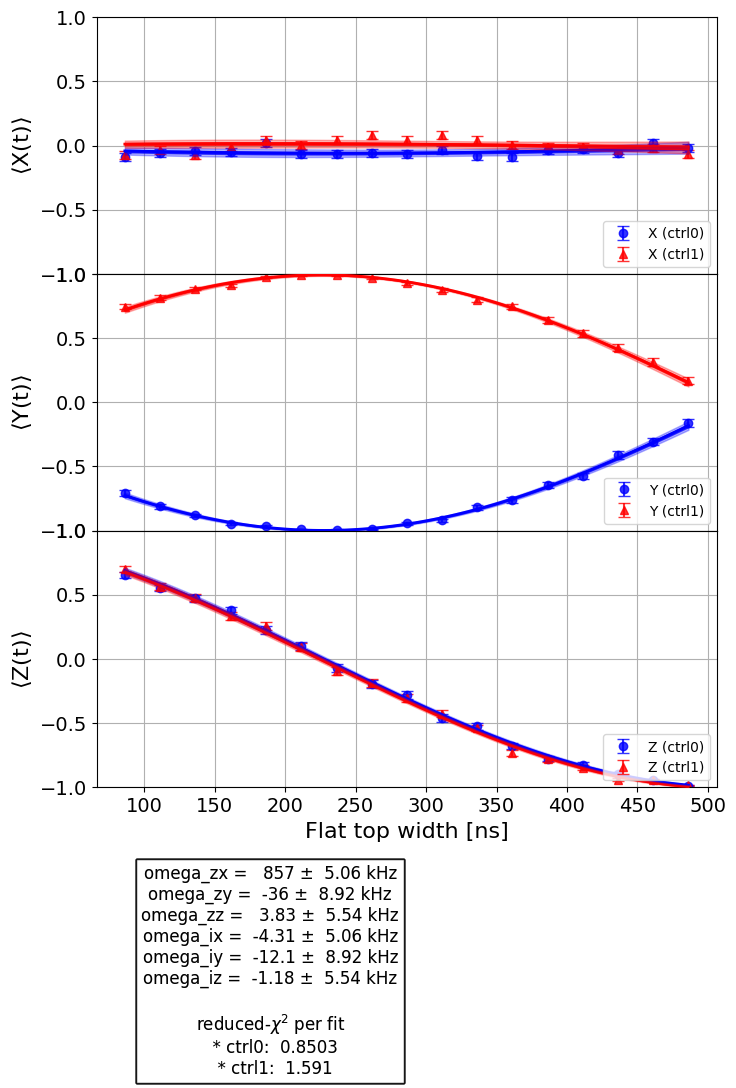

In [58]:
data_cr.figure(0)

In [59]:
angle_amp(resonance_7*8.5/7,0.0004)

(0.027627895775827735, 0.01447862620309404)

In [60]:
angle_amp(0.01,0.0004)

(0.010007996802557442, 0.039978687123290044)

In [61]:
import math

# 주어진 크기와 각도 (각도는 라디안 단위)
r = 5
theta = math.radians(53.13)  # 도 단위의 각도를 라디안으로 변환

# 실수항과 허수항 계산
real = r * math.cos(theta)
imag = r * math.sin(theta)

# 결과 출력
print(f"실수항 (real): {real}")
print(f"허수항 (imag): {imag}")

실수항 (real): 3.0000071456633126
허수항 (imag): 3.999994640742543


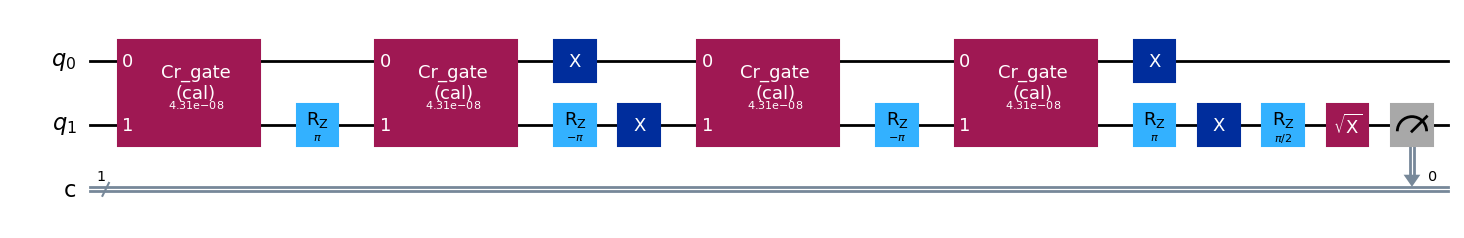

In [75]:
from qiskit_experiments.library import CrossResonanceHamiltonian
from qiskit.circuit import Gate
cr_ham_experiment = EchoedCrossResonanceHamiltonian_double(
    physical_qubits=(1, 0),
    durations=np.linspace(1e-7, 3e-7, 17),
    amp = 0.3,
    amp_t = 0.02275351621178582,
    backend=backend,
    c_angle = 0,
    x_angle = 0.01758060610063206,

)


backend.target.update_from_instruction_schedule_map(cals.get_inst_map())
cr_ham_experiment.circuits()[0].draw("mpl")

In [86]:
cals.get_inst_map()

In [82]:
schedule(cr_ham_experiment.circuits()[0],backend=backend).draw()

QiskitError: "Operation 'cr_gate' on qubit(s) [0, 1] not supported by the backend command definition. Did you remember to transpile your input circuit for the same backend?"

In [76]:
%time data_cr = cr_ham_experiment.run().block_for_results()

CPU times: user 49.3 s, sys: 2.68 s, total: 51.9 s
Wall time: 49.3 s


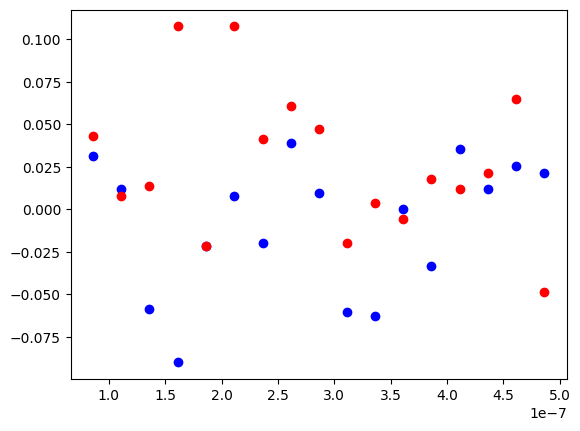

In [78]:
# 첫 번째 플롯
import matplotlib.pyplot as plt
x_list =[]
data_list_0 = []
data_list_1 = []

for data in data_cr.data():
  if data['metadata']['meas_basis'] == 'x':
    if data['metadata']['control_state'] == 0:
        x_list.append(data['metadata']['xval'])
        try:
          count_1 = data['counts']['1']
        except:
          count_1 =0
        data_list_0.append((data['counts']['0']-count_1)/(data['counts']['0']+count_1))
    else:
        try:
            count_1 = data['counts']['1']
        except:
          count_1 =0
        data_list_1.append((data['counts']['0']-count_1)/(data['counts']['0']+count_1))

plt.plot(x_list,data_list_0,'bo')
plt.plot(x_list,data_list_1,'ro')

#plt.ylim(,1)
plt.show() # 0.0025*9.1*2

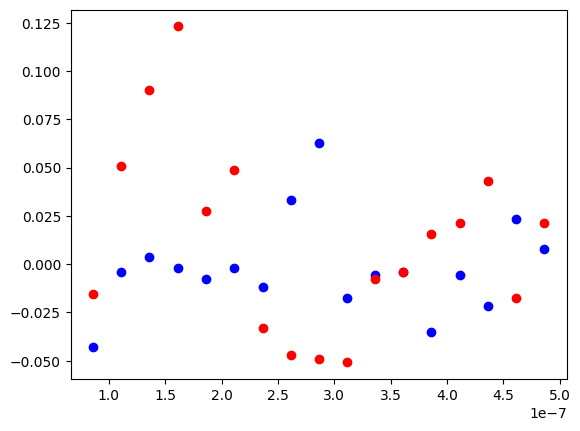

In [68]:
# 첫 번째 플롯 ##  완벽하게 fitting한 값
import matplotlib.pyplot as plt
x_list =[]
data_list_0 = []
data_list_1 = []

for data in data_cr.data():
  if data['metadata']['meas_basis'] == 'x':
    if data['metadata']['control_state'] == 0:
        x_list.append(data['metadata']['xval'])
        try:
          count_1 = data['counts']['1']
        except:
          count_1 =0
        data_list_0.append((data['counts']['0']-count_1)/(data['counts']['0']+count_1))
    else:
        try:
            count_1 = data['counts']['1']
        except:
          count_1 =0
        data_list_1.append((data['counts']['0']-count_1)/(data['counts']['0']+count_1))

plt.plot(x_list,data_list_0,'bo')
plt.plot(x_list,data_list_1,'ro')
#plt.ylim(0.99,1)
plt.show() # 0.0025*9.1*2

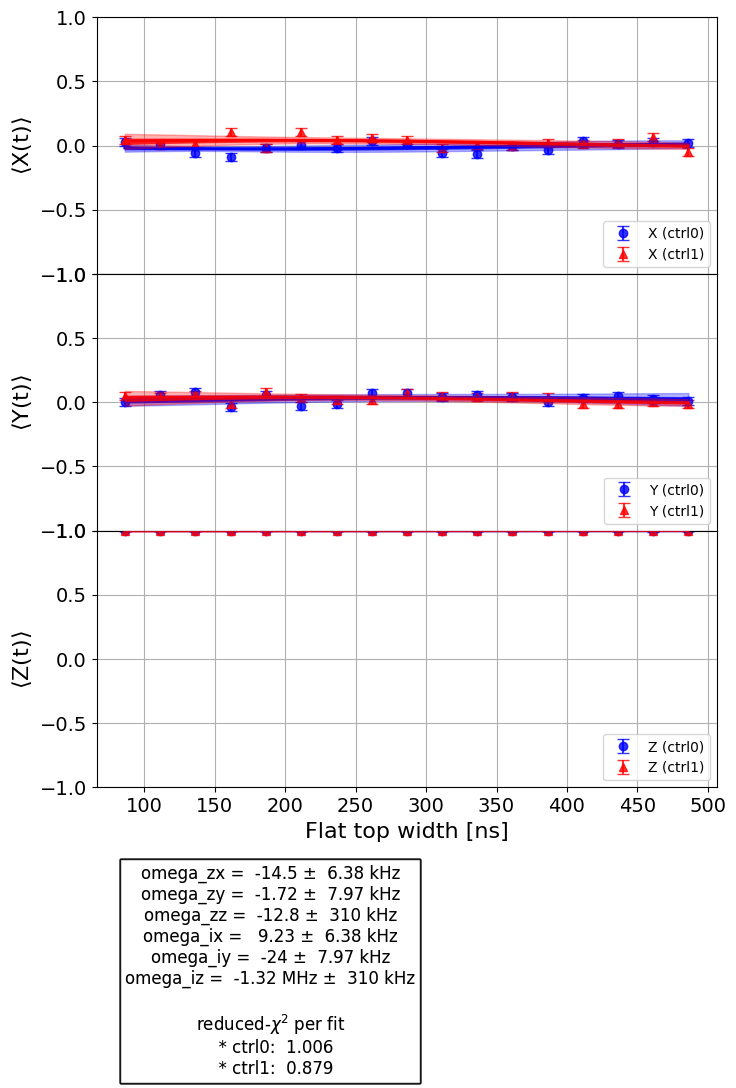

In [79]:
data_cr.figure(0)

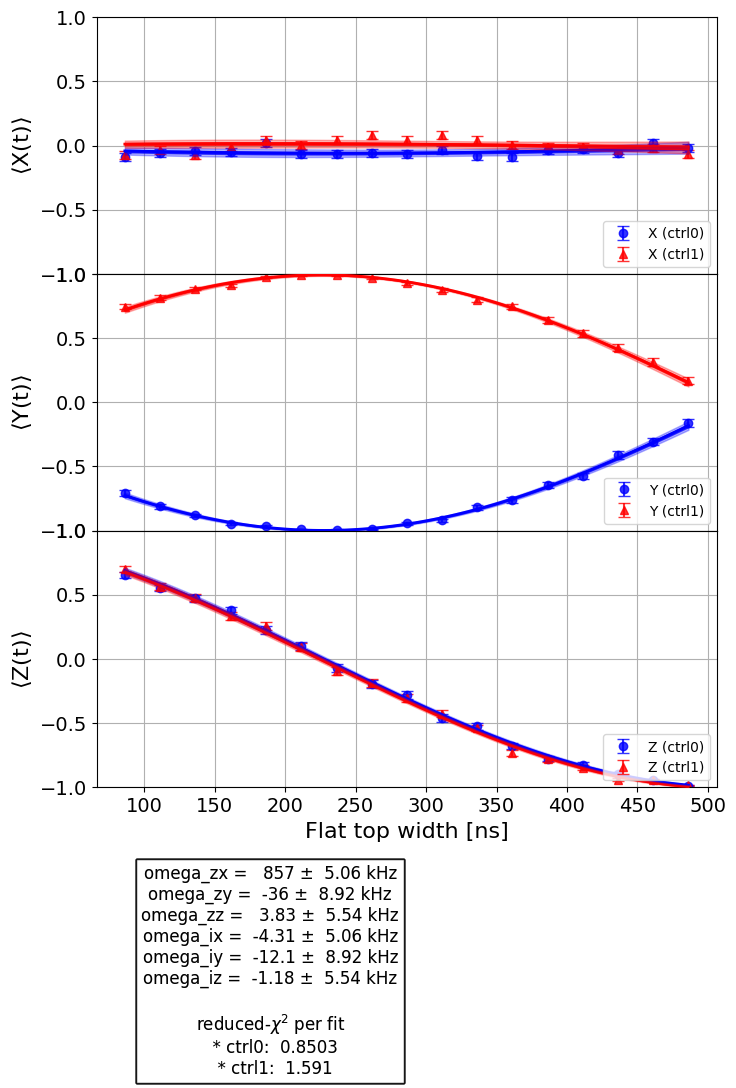

In [64]:
data_cr.figure(0)